# Notebook 05: KPI Computation & Final Load Preparation

**Problem Statement:** Real estate investors lack a standardized, data-driven framework to identify undervalued properties across 10 diverse US states, leading to inefficient capital allocation and suboptimal ROI on property flips.

**Decision Question:** Which specific combinations of state and bedroom-count currently offer the lowest average price-per-square-foot, identifying the most lucrative entry points for high-margin property acquisitions?

**Decision Supported:** Enable real estate fund managers to reallocate investment capital away from saturated, high-priced states and towards specific *Value-Zip-Codes* where price-per-sqft is statistically lower than the state average but historical demand remains high.

| KPI | Description |
|---|---|
| **KPI 1** | Average Price per Square Foot — by State x Bedroom Count |
| **KPI 2** | Inventory Concentration Index — by State / City |

**Expected Insight:** A strong negative correlation between house size and price/sqft, where Studio/1-bed urban properties (CA, NY) command a significantly higher premium per sqft compared to larger 5-bed suburban estates (FL).

---

## 1. Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14

df = pd.read_csv('../data/processed/cleaned_house_data.csv', parse_dates=['date'])



# Core derived columns
df['price_per_sqft'] = df['price'] / df['house_sqft']
df['log_price']      = np.log1p(df['price'])
df['log_sqft']       = np.log1p(df['house_sqft'])
df['has_broker']     = (df['broker'] != 'Unknown').astype(int)
df['month']          = df['date'].dt.to_period('M')
df['month_num']      = df['date'].dt.month
df['day_of_week']    = df['date'].dt.dayofweek
df['is_weekend']     = (df['day_of_week'] >= 5).astype(int)
df['bed_bath_ratio'] = df['bed'] / df['bath'].replace(0, np.nan)

# Bedroom category label
def bed_label(b):
    if b == 0:   return 'Studio'
    elif b == 1: return '1 Bed'
    elif b == 2: return '2 Bed'
    elif b == 3: return '3 Bed'
    elif b == 4: return '4 Bed'
    else:        return '5+ Bed'

BED_ORDER = ['Studio', '1 Bed', '2 Bed', '3 Bed', '4 Bed', '5+ Bed']
df['bed_category'] = pd.Categorical(df['bed'].apply(bed_label), categories=BED_ORDER, ordered=True)

# House size category
def size_label(s):
    if s < 800:    return 'Tiny (<800)'
    elif s < 1500: return 'Small (800-1500)'
    elif s < 2500: return 'Medium (1500-2500)'
    elif s < 4000: return 'Large (2500-4000)'
    else:          return 'XL (4000+)'

df['size_category'] = df['house_sqft'].apply(size_label)

print(f'Dataset: {len(df):,} rows  |  {df["state_name"].nunique()} states  |  {df["city"].nunique()} cities')
df.head(3)

Dataset: 11,410 rows  |  10 states  |  2224 cities


,date,bed,bath,price,broker,street,city,state_name,zip_code,house_sqft,...,log_price,log_sqft,has_broker,month,month_num,day_of_week,is_weekend,bed_bath_ratio,bed_category,size_category
0,2024-08-29,4.0,4.0,415000.0,Unknown,2004 W 23rd Ct,Panama City,Florida,32405,2520.0,...,12.936036,7.832411,0,2024-08,8,3,0,1.0,4 Bed,Large (2500-4000)
1,2024-08-29,2.0,2.0,58000.0,Unknown,5390 Webb St,Graceville,Florida,32440,704.0,...,10.968216,6.558198,0,2024-08,8,3,0,1.0,2 Bed,Tiny (<800)
2,2024-08-29,3.0,3.0,375000.0,Coldwell Banker Hartung,6761 Landover Cir,Tallahassee,Florida,32317,1926.0,...,12.834684,7.563720,1,2024-08,8,3,0,1.0,3 Bed,Medium (1500-2500)


---
## 2. KPI 1: Average Price per Square Foot

> *"Which specific combinations of state and bedroom-count currently offer the lowest average price-per-square-foot?"*

### 2.1 National Baseline $/sqft

In [4]:
# Cap top-1% outliers for stable averages
p99 = df['price_per_sqft'].quantile(0.99)
df_clean = df[df['price_per_sqft'] <= p99].copy()

national_avg_ppsqft = df_clean['price_per_sqft'].mean()
national_med_ppsqft = df_clean['price_per_sqft'].median()

print(f'National Average $/sqft  : ${national_avg_ppsqft:,.2f}')
print(f'National Median  $/sqft  : ${national_med_ppsqft:,.2f}')
print(f'Outlier cap applied at   : ${p99:,.2f}')

National Average $/sqft  : $327.35
National Median  $/sqft  : $261.50
Outlier cap applied at   : $1,430.92


### 2.2 Average $/sqft by State

,state_name,avg_ppsqft,median_ppsqft,count,std_ppsqft,vs_national_avg,pct_vs_national
0,Alabama,166.10,156.70,919,82.19,-161.25,-49.3
1,Illinois,191.88,181.07,965,101.01,-135.47,-41.4
2,North Carolina,216.10,200.07,943,94.65,-111.25,-34.0
3,South Carolina,233.00,194.87,903,143.37,-94.35,-28.8
4,Florida,254.98,204.89,992,164.62,-72.37,-22.1
5,Arizona,266.89,246.00,1024,112.69,-60.46,-18.5
6,New York,328.08,260.71,994,239.44,0.73,0.2
7,Washington,365.55,323.14,949,165.74,38.20,11.7
8,Louisiana,393.07,379.99,949,112.62,65.72,20.1
9,California,516.74,475.98,2658,261.62,189.39,57.9


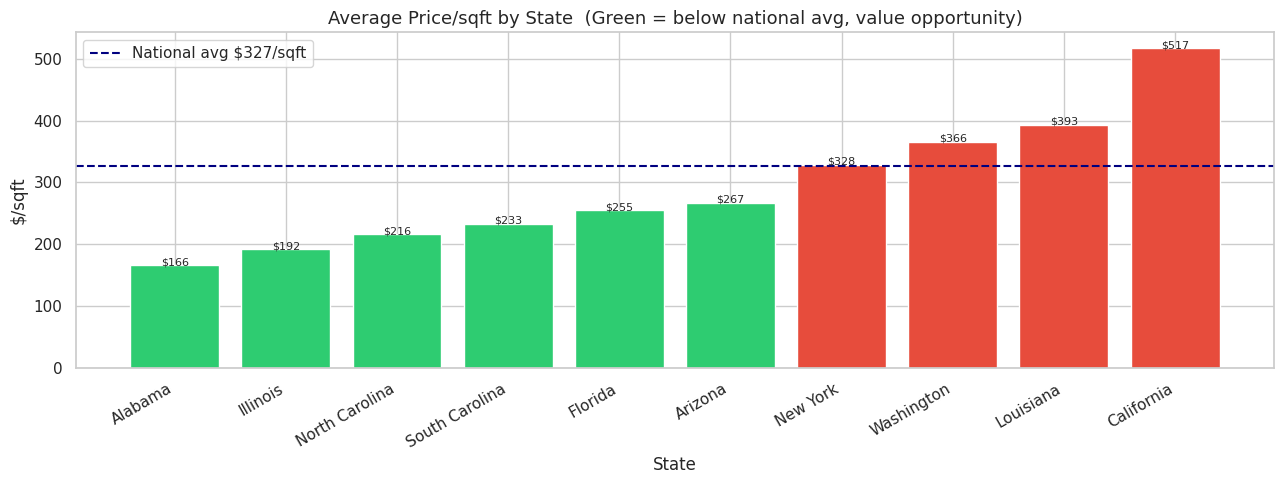

In [5]:
state_ppsqft = (
    df_clean.groupby('state_name')['price_per_sqft']
    .agg(avg_ppsqft='mean', median_ppsqft='median', count='count', std_ppsqft='std')
    .round(2)
    .sort_values('avg_ppsqft')
    .reset_index()
)
state_ppsqft['vs_national_avg'] = (state_ppsqft['avg_ppsqft'] - national_avg_ppsqft).round(2)
state_ppsqft['pct_vs_national'] = (100 * state_ppsqft['vs_national_avg'] / national_avg_ppsqft).round(1)

display(state_ppsqft)

# Chart
colors = ['#2ecc71' if v < 0 else '#e74c3c' for v in state_ppsqft['vs_national_avg']]
fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(state_ppsqft['state_name'], state_ppsqft['avg_ppsqft'], color=colors, edgecolor='white')
ax.axhline(national_avg_ppsqft, color='navy', linestyle='--', linewidth=1.5,
           label=f'National avg ${national_avg_ppsqft:.0f}/sqft')
ax.set_title('Average Price/sqft by State  (Green = below national avg, value opportunity)', fontsize=13)
ax.set_ylabel('$/sqft')
ax.set_xlabel('State')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, state_ppsqft['avg_ppsqft']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'${val:.0f}', ha='center', fontsize=8)
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 Average $/sqft by Bedroom Count

,bed_category,avg_ppsqft,median_ppsqft,count
0,Studio,337.51,275.12,150
1,1 Bed,454.60,410.93,282
2,2 Bed,354.20,292.60,1773
3,3 Bed,313.23,252.69,5136
4,4 Bed,318.55,253.38,2965
5,5+ Bed,341.11,273.98,990


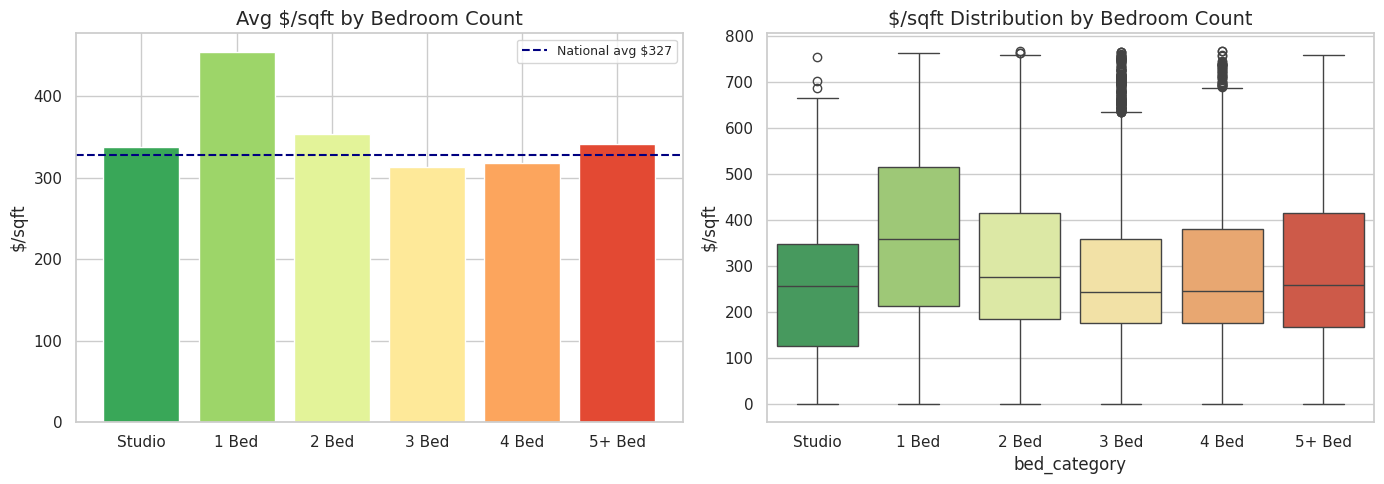

In [6]:
bed_ppsqft = (
    df_clean.groupby('bed_category', observed=True)['price_per_sqft']
    .agg(avg_ppsqft='mean', median_ppsqft='median', count='count')
    .round(2)
    .reset_index()
)
display(bed_ppsqft)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(bed_ppsqft['bed_category'].astype(str), bed_ppsqft['avg_ppsqft'],
            color=sns.color_palette('RdYlGn_r', len(bed_ppsqft)), edgecolor='white')
axes[0].axhline(national_avg_ppsqft, color='navy', linestyle='--', linewidth=1.5,
                label=f'National avg ${national_avg_ppsqft:.0f}')
axes[0].set_title('Avg $/sqft by Bedroom Count')
axes[0].set_ylabel('$/sqft')
axes[0].legend(fontsize=9)

sns.boxplot(
    data=df_clean[df_clean['price_per_sqft'] < df_clean['price_per_sqft'].quantile(0.95)],
    x='bed_category', y='price_per_sqft', order=BED_ORDER,
    palette='RdYlGn_r', ax=axes[1]
)
axes[1].set_title('$/sqft Distribution by Bedroom Count')
axes[1].set_ylabel('$/sqft')

plt.tight_layout()
plt.show()

### 2.4 Core KPI 1 Table: Average $/sqft by State x Bedroom Count

> The primary decision table for fund managers. This heatmap directly answers the decision question.

In [7]:
kpi1_pivot = (
    df_clean.groupby(['state_name', 'bed_category'], observed=True)['price_per_sqft']
    .mean()
    .round(2)
    .unstack('bed_category')
)
kpi1_pivot.columns = kpi1_pivot.columns.astype(str)
kpi1_pivot['State Avg'] = kpi1_pivot.mean(axis=1).round(2)
kpi1_pivot = kpi1_pivot.sort_values('State Avg')  # cheapest states at top

print('Average Price/sqft ($/sqft) --- State x Bedroom Count')
print('Sorted: cheapest states at top. Green = lowest $/sqft = best value entry.')
display(kpi1_pivot.style
    .format('${:.0f}', na_rep='---')
    .background_gradient(cmap='RdYlGn_r', axis=None, subset=list(kpi1_pivot.columns[:-1]))
    .set_caption('Red = highest $/sqft (expensive) | Green = lowest $/sqft (value opportunity)')
)

Average Price/sqft ($/sqft) --- State x Bedroom Count
Sorted: cheapest states at top. Green = lowest $/sqft = best value entry.


bed_category,Studio,1 Bed,2 Bed,3 Bed,4 Bed,5+ Bed,State Avg
state_name,,,,,,,
Alabama,$65,$266,$202,$160,$168,$159,$170
North Carolina,$30,$215,$229,$218,$212,$216,$187
Illinois,$147,$198,$197,$181,$190,$229,$190
South Carolina,$170,$427,$231,$220,$253,$229,$255
Arizona,$260,$284,$260,$270,$264,$272,$268
Florida,$398,$349,$300,$232,$248,$270,$299
New York,$353,$610,$334,$299,$274,$392,$377
Washington,$523,$543,$411,$350,$353,$342,$420
Louisiana,$388,$583,$413,$368,$416,$413,$430


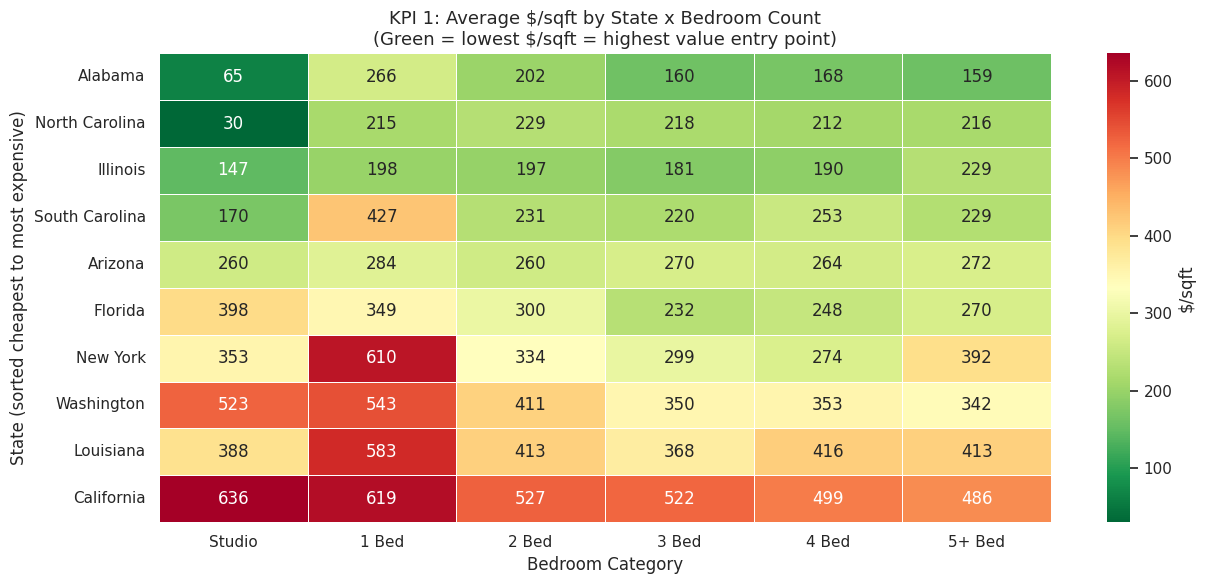

In [8]:
# Heatmap version
fig, ax = plt.subplots(figsize=(13, 6))
heatmap_data = kpi1_pivot.drop(columns=['State Avg'])
sns.heatmap(
    heatmap_data.astype(float),
    annot=True, fmt='.0f', cmap='RdYlGn_r',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': '$/sqft'}
)
ax.set_title('KPI 1: Average $/sqft by State x Bedroom Count\n(Green = lowest $/sqft = highest value entry point)', fontsize=13)
ax.set_xlabel('Bedroom Category')
ax.set_ylabel('State (sorted cheapest to most expensive)')
plt.tight_layout()
plt.show()

### 2.5 Top 10 Best-Value State x Bedroom Combinations

> Ranked entry points sorted by lowest average $/sqft, filtered to min 20 listings for statistical reliability.

In [9]:
kpi1_long = (
    df_clean.groupby(['state_name', 'bed_category'], observed=True)
    .agg(
        avg_ppsqft     = ('price_per_sqft', 'mean'),
        median_ppsqft  = ('price_per_sqft', 'median'),
        listing_count  = ('price_per_sqft', 'count'),
        avg_price      = ('price', 'mean'),
        median_price   = ('price', 'median'),
        avg_sqft       = ('house_sqft', 'mean'),
    )
    .round(2)
    .reset_index()
)

# Attach state avg for context
kpi1_long = kpi1_long.merge(
    state_ppsqft[['state_name', 'avg_ppsqft']].rename(columns={'avg_ppsqft': 'state_avg_ppsqft'}),
    on='state_name'
)
kpi1_long['discount_vs_state'] = (kpi1_long['state_avg_ppsqft'] - kpi1_long['avg_ppsqft']).round(2)
kpi1_long['pct_below_state']   = (100 * kpi1_long['discount_vs_state'] / kpi1_long['state_avg_ppsqft']).round(1)

top_value = (
    kpi1_long[kpi1_long['listing_count'] >= 20]
    .sort_values('avg_ppsqft')
    .head(10)
    .reset_index(drop=True)
)
top_value.index += 1

display(top_value[['state_name', 'bed_category', 'avg_ppsqft', 'median_ppsqft',
                   'avg_price', 'avg_sqft', 'listing_count', 'pct_below_state']].rename(columns={
    'state_name': 'State', 'bed_category': 'Bed Type',
    'avg_ppsqft': 'Avg $/sqft', 'median_ppsqft': 'Median $/sqft',
    'avg_price': 'Avg Price ($)', 'avg_sqft': 'Avg Sqft',
    'listing_count': 'Listings', 'pct_below_state': '% Below State Avg'
}))

,State,Bed Type,Avg $/sqft,Median $/sqft,Avg Price ($),Avg Sqft,Listings,% Below State Avg
1,Alabama,5+ Bed,158.63,144.74,617144.85,3792.54,67,4.5
2,Alabama,3 Bed,160.27,155.77,274114.45,1691.38,460,3.5
3,Alabama,4 Bed,168.22,161.50,424817.66,2515.38,311,-1.3
4,Illinois,3 Bed,181.01,165.78,320191.01,1760.22,391,5.7
5,Illinois,4 Bed,190.37,186.24,465289.73,2427.68,202,0.8
6,Illinois,2 Bed,197.06,184.56,258270.84,1287.73,236,-2.7
7,Illinois,1 Bed,198.21,197.97,170445.95,858.71,37,-3.3
8,Alabama,2 Bed,201.87,166.14,228631.15,1155.70,68,-21.5
9,North Carolina,4 Bed,212.07,187.60,578587.85,2601.78,234,1.9
10,North Carolina,5+ Bed,215.77,191.58,788402.85,3506.91,68,0.2


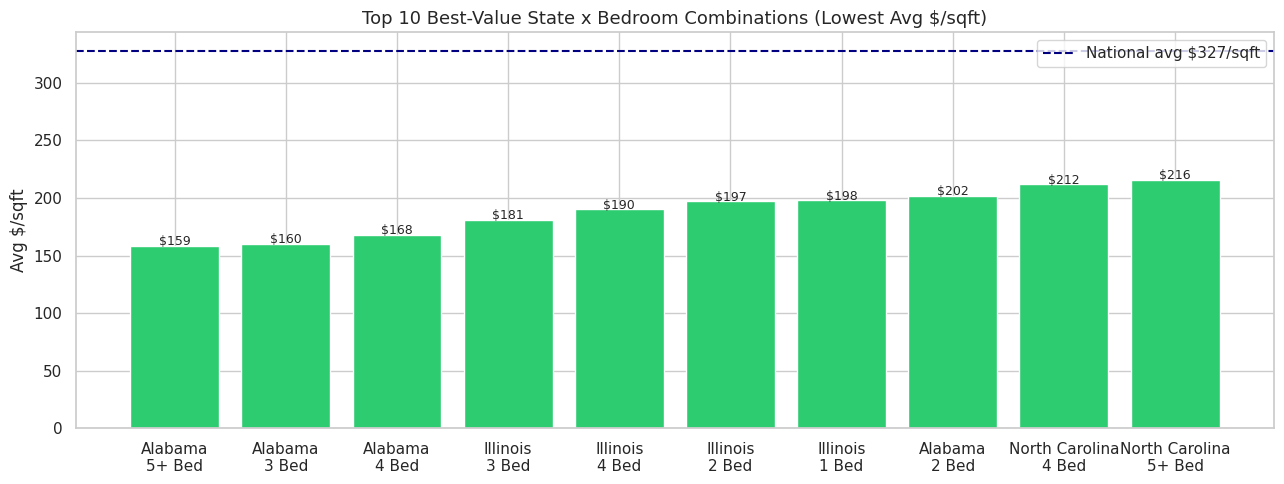

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
labels = top_value['state_name'] + '\n' + top_value['bed_category'].astype(str)
bars = ax.bar(labels, top_value['avg_ppsqft'], color='#2ecc71', edgecolor='white')
ax.axhline(national_avg_ppsqft, color='navy', linestyle='--', linewidth=1.5,
           label=f'National avg ${national_avg_ppsqft:.0f}/sqft')
ax.set_title('Top 10 Best-Value State x Bedroom Combinations (Lowest Avg $/sqft)', fontsize=13)
ax.set_ylabel('Avg $/sqft')
for bar, val in zip(bars, top_value['avg_ppsqft']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'${val:.0f}', ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. KPI 2: Inventory Concentration Index (ICI)

> **Definition:** ICI measures how concentrated listings are across states and cities using the Herfindahl-Hirschman Index (HHI).
>
> Formula: `ICI = sum((share_i)^2)` where `share_i = listings_in_location / total_listings`
>
> A high ICI (close to 1) = inventory monopolised by a few locations (low competition diversity).  
> A low ICI = dispersed, competitive market with more entry opportunities.

### 3.1 State-Level ICI

In [11]:
total_listings = len(df_clean)

state_counts = df_clean['state_name'].value_counts().reset_index()
state_counts.columns = ['state_name', 'listing_count']
state_counts['share']     = state_counts['listing_count'] / total_listings
state_counts['share_sq']  = state_counts['share'] ** 2
state_counts['share_pct'] = (state_counts['share'] * 100).round(2)

ici_state = state_counts['share_sq'].sum()

print(f'Inventory Concentration Index (State level): {ici_state:.4f}')
print(f'Equivalent uniform states: {1/ici_state:.1f}  (perfect = {state_counts.shape[0]})')

if ici_state > 0.18:
    print('  HIGH concentration (HHI > 0.18) -- inventory dominated by few states')
elif ici_state > 0.10:
    print('  MODERATE concentration (HHI 0.10-0.18)')
else:
    print('  LOW concentration (HHI < 0.10) -- well-dispersed inventory')

display(state_counts.sort_values('share', ascending=False))

Inventory Concentration Index (State level): 0.1204
Equivalent uniform states: 8.3  (perfect = 10)
  MODERATE concentration (HHI 0.10-0.18)


,state_name,listing_count,share,share_sq,share_pct
0,California,2658,0.235305,0.055368,23.53
1,Arizona,1024,0.090652,0.008218,9.07
2,New York,994,0.087996,0.007743,8.80
3,Florida,992,0.087819,0.007712,8.78
4,Illinois,965,0.085428,0.007298,8.54
5,Louisiana,949,0.084012,0.007058,8.40
6,Washington,949,0.084012,0.007058,8.40
7,North Carolina,943,0.083481,0.006969,8.35
8,Alabama,919,0.081356,0.006619,8.14
9,South Carolina,903,0.079940,0.006390,7.99


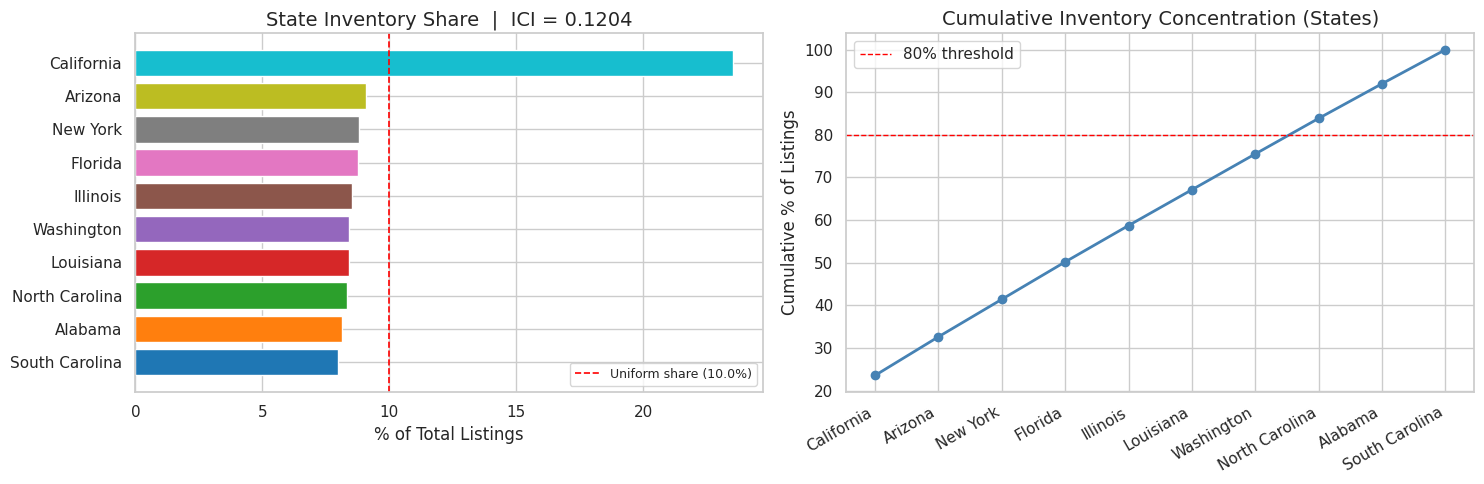

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sorted_states = state_counts.sort_values('share', ascending=True)
axes[0].barh(sorted_states['state_name'], sorted_states['share_pct'],
             color=sns.color_palette('tab10', len(sorted_states)))
axes[0].axvline(100 / len(sorted_states), color='red', linestyle='--', linewidth=1.2,
                label=f'Uniform share ({100/len(sorted_states):.1f}%)')
axes[0].set_title(f'State Inventory Share  |  ICI = {ici_state:.4f}')
axes[0].set_xlabel('% of Total Listings')
axes[0].legend(fontsize=9)

# Cumulative concentration curve
sorted_desc = state_counts.sort_values('share', ascending=False)
cumulative  = sorted_desc['share'].cumsum().values
x_pos       = np.arange(1, len(cumulative) + 1)
axes[1].plot(x_pos, cumulative * 100, marker='o', color='steelblue', linewidth=2)
axes[1].axhline(80, color='red', linestyle='--', linewidth=1, label='80% threshold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(sorted_desc['state_name'], rotation=30, ha='right')
axes[1].set_title('Cumulative Inventory Concentration (States)')
axes[1].set_ylabel('Cumulative % of Listings')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2 City-Level ICI

In [13]:
city_counts = df_clean.groupby(['state_name', 'city']).size().reset_index(name='listing_count')
city_counts['share']     = city_counts['listing_count'] / total_listings
city_counts['share_sq']  = city_counts['share'] ** 2
city_counts['share_pct'] = (city_counts['share'] * 100).round(3)

ici_city = city_counts['share_sq'].sum()
top30_cities = city_counts.sort_values('listing_count', ascending=False).head(30).reset_index(drop=True)
top30_cities.index += 1

print(f'Inventory Concentration Index (City level): {ici_city:.6f}')
print(f'Equivalent uniform cities: {1/ici_city:.0f}  (actual = {city_counts.shape[0]})')
print(f'Top 30 cities account for: {top30_cities["share_pct"].sum():.1f}% of all listings')

display(top30_cities.head(15))

Inventory Concentration Index (City level): 0.002184
Equivalent uniform cities: 458  (actual = 2364)
Top 30 cities account for: 19.0% of all listings


,state_name,city,listing_count,share,share_sq,share_pct
1,Illinois,Chicago,150,0.013279,0.000176,1.328
2,Arizona,Phoenix,135,0.011951,0.000143,1.195
3,Louisiana,Baton Rouge,121,0.010712,0.000115,1.071
4,Florida,Pensacola,120,0.010623,0.000113,1.062
5,Florida,Tallahassee,113,0.010004,0.000100,1.000
6,Arizona,Tucson,109,0.009649,0.000093,0.965
7,Louisiana,New Orleans,89,0.007879,0.000062,0.788
8,Alabama,Birmingham,82,0.007259,0.000053,0.726
9,North Carolina,Charlotte,77,0.006817,0.000046,0.682
10,California,Los Angeles,77,0.006817,0.000046,0.682


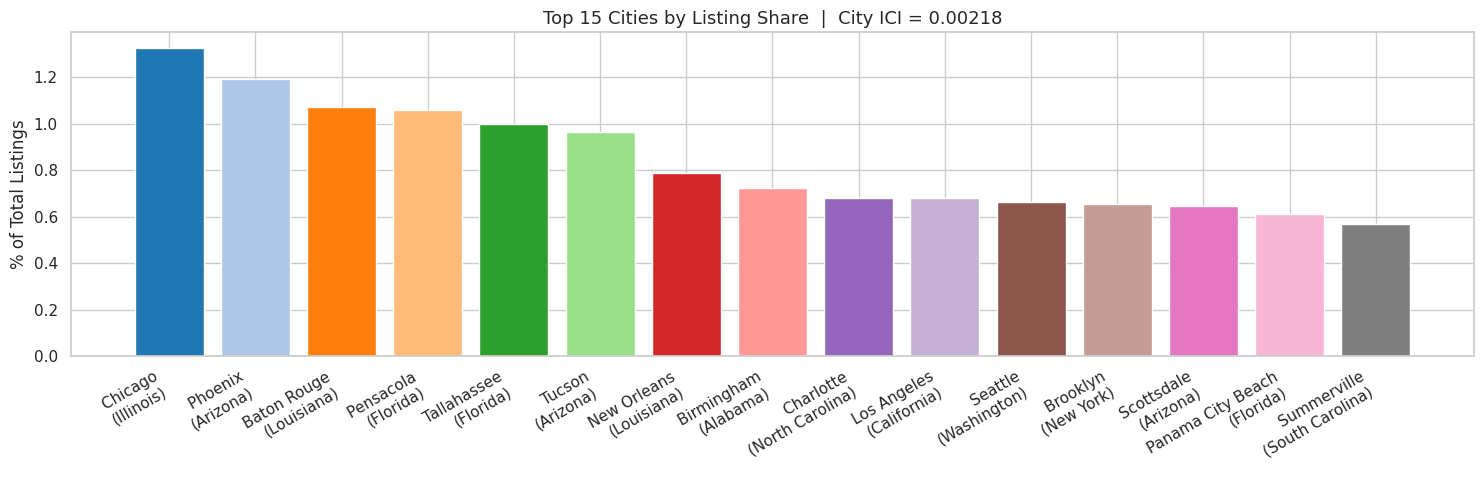

In [14]:
fig, ax = plt.subplots(figsize=(15, 5))
top15 = top30_cities.head(15)
city_labels = top15['city'] + '\n(' + top15['state_name'] + ')'
ax.bar(city_labels, top15['share_pct'], color=sns.color_palette('tab20', 15), edgecolor='white')
ax.set_title(f'Top 15 Cities by Listing Share  |  City ICI = {ici_city:.5f}', fontsize=13)
ax.set_ylabel('% of Total Listings')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 3.3 Within-State City Concentration

> For each state: how concentrated are listings within its cities? States with a high within-state ICI have lopsided demand concentrated in 1-2 cities, which distorts state-level $/sqft signals.

,state_name,within_state_ici,total_listings,num_cities
0,Arizona,0.0477,1024,100
1,Florida,0.0461,992,122
2,Louisiana,0.0398,949,145
3,Illinois,0.0288,965,318
4,South Carolina,0.0244,903,143
5,Alabama,0.0206,919,187
6,Washington,0.0189,949,184
7,North Carolina,0.0170,943,258
8,New York,0.0126,994,392
9,California,0.0055,2658,515


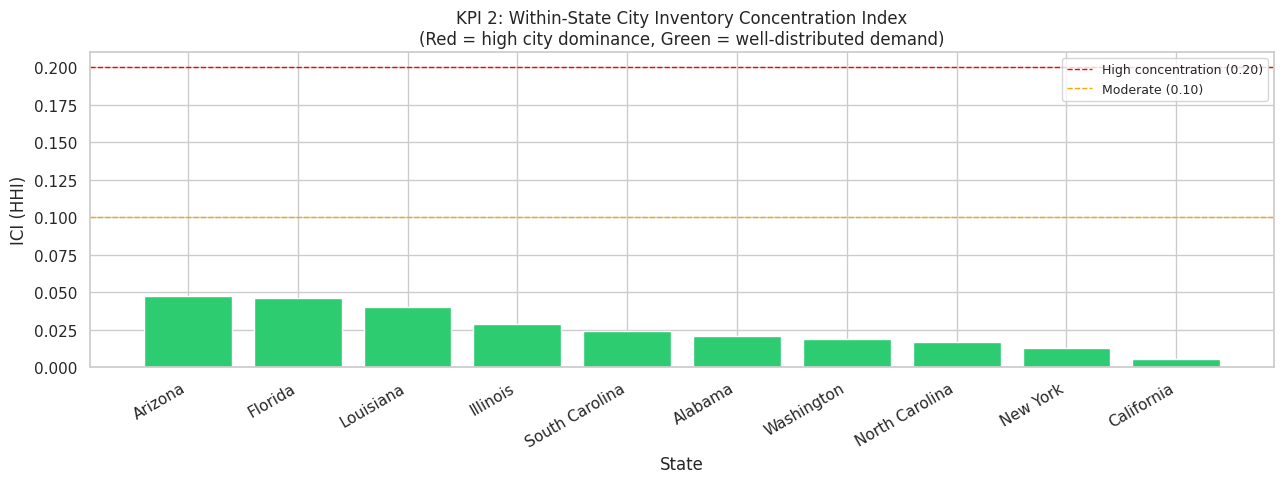

In [15]:
def compute_ici(group):
    shares = group / group.sum()
    return (shares ** 2).sum()

within_state_ici = (
    df_clean.groupby(['state_name', 'city'])
    .size()
    .reset_index(name='count')
    .groupby('state_name')['count']
    .apply(compute_ici)
    .reset_index(name='within_state_ici')
    .sort_values('within_state_ici', ascending=False)
    .reset_index(drop=True)
)

state_meta = df_clean.groupby('state_name').agg(
    total_listings = ('price', 'count'),
    num_cities     = ('city', 'nunique')
).reset_index()
within_state_ici = within_state_ici.merge(state_meta, on='state_name')
within_state_ici['within_state_ici'] = within_state_ici['within_state_ici'].round(4)

display(within_state_ici)

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#e74c3c' if v > 0.20 else '#f39c12' if v > 0.10 else '#2ecc71'
          for v in within_state_ici['within_state_ici']]
ax.bar(within_state_ici['state_name'], within_state_ici['within_state_ici'],
       color=colors, edgecolor='white')
ax.axhline(0.20, color='red',    linestyle='--', linewidth=1, label='High concentration (0.20)')
ax.axhline(0.10, color='orange', linestyle='--', linewidth=1, label='Moderate (0.10)')
ax.set_title('KPI 2: Within-State City Inventory Concentration Index\n(Red = high city dominance, Green = well-distributed demand)', fontsize=12)
ax.set_ylabel('ICI (HHI)')
ax.set_xlabel('State')
plt.xticks(rotation=30, ha='right')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 4. Value Zip Code Identification

> **Definition:** A Value-Zip-Code satisfies all three criteria:
> 1. Average $/sqft is **statistically below** its state average (Z-score < -0.5)
> 2. **High demand** (listing count >= state ZIP-level median count)
> 3. **Minimum 5 listings** for statistical reliability

In [16]:
zip_agg = (
    df_clean.groupby(['state_name', 'zip_code'])
    .agg(
        listing_count = ('price', 'count'),
        avg_ppsqft    = ('price_per_sqft', 'mean'),
        median_ppsqft = ('price_per_sqft', 'median'),
        avg_price     = ('price', 'mean'),
        median_price  = ('price', 'median'),
        avg_sqft      = ('house_sqft', 'mean'),
    )
    .round(2)
    .reset_index()
)

# Z-score of $/sqft within each state
zip_agg['ppsqft_zscore'] = zip_agg.groupby('state_name')['avg_ppsqft'].transform(
    lambda x: stats.zscore(x, ddof=1) if len(x) > 1 else 0
).round(3)

# High demand = listing count >= state median count
zip_agg['state_median_count'] = zip_agg.groupby('state_name')['listing_count'].transform('median')
zip_agg['high_demand']        = (zip_agg['listing_count'] >= zip_agg['state_median_count']).astype(int)

# Apply Value ZIP filter
value_zips = zip_agg[
    (zip_agg['ppsqft_zscore'] < -0.5) &
    (zip_agg['high_demand'] == 1) &
    (zip_agg['listing_count'] >= 5)
].copy().sort_values('ppsqft_zscore').reset_index(drop=True)
value_zips.index += 1

print(f'Value-Zip-Codes identified: {len(value_zips):,}  across {value_zips["state_name"].nunique()} states')
print('\nTop 20 Value Zip Codes (lowest $/sqft with high demand):')
display(value_zips[['state_name', 'zip_code', 'avg_ppsqft', 'median_price',
                     'avg_sqft', 'listing_count', 'ppsqft_zscore']].head(20))

Value-Zip-Codes identified: 183  across 10 states

Top 20 Value Zip Codes (lowest $/sqft with high demand):


,state_name,zip_code,avg_ppsqft,median_price,avg_sqft,listing_count,ppsqft_zscore
1,Illinois,62526,51.01,85000.0,1079.00,7,-1.432
2,Illinois,62521,53.74,68500.0,1715.40,5,-1.399
3,Illinois,61604,54.63,50000.0,1241.17,6,-1.389
4,California,93306,189.23,457495.0,2421.48,10,-1.336
5,Arizona,85650,143.06,387500.0,2108.33,6,-1.239
6,Arizona,85122,145.13,224000.0,1611.78,9,-1.218
7,California,93308,219.57,267000.0,1242.00,8,-1.218
8,California,93257,220.53,276000.0,1314.40,5,-1.214
9,California,92392,222.39,496744.0,2373.50,6,-1.207
10,California,93292,224.03,589000.0,2765.83,6,-1.200


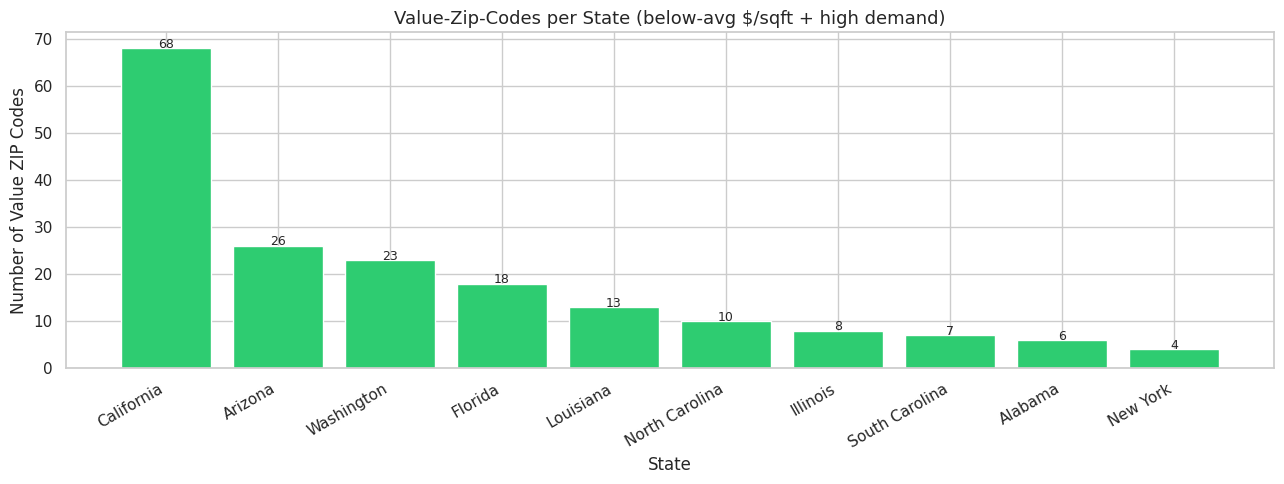

In [17]:
# Value ZIPs per state
value_by_state = value_zips['state_name'].value_counts().reset_index()
value_by_state.columns = ['state_name', 'value_zip_count']

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(value_by_state['state_name'], value_by_state['value_zip_count'],
       color='#2ecc71', edgecolor='white')
ax.set_title('Value-Zip-Codes per State (below-avg $/sqft + high demand)', fontsize=13)
ax.set_ylabel('Number of Value ZIP Codes')
ax.set_xlabel('State')
plt.xticks(rotation=30, ha='right')
for i, (_, row) in enumerate(value_by_state.iterrows()):
    ax.text(i, row['value_zip_count'] + 0.1, str(int(row['value_zip_count'])), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Expected Insight Validation

> *"We expect a strong negative correlation between house_size and price/sqft — smaller Studio/1-bed urban properties (CA, NY) command a significantly higher $/sqft premium vs larger 5-bed suburban estates (FL)."*

### 5.1 Correlation: House Size vs. $/sqft

In [18]:
r_pearson,  p_pearson  = stats.pearsonr(df_clean['house_sqft'], df_clean['price_per_sqft'])
r_spearman, p_spearman = stats.spearmanr(df_clean['house_sqft'], df_clean['price_per_sqft'])

print('Hypothesis: Negative correlation between house_size and price/sqft')
print(f'  Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.2e})')
print(f'  Spearman r = {r_spearman:.4f}  (p = {p_spearman:.2e})')

if r_pearson < -0.2 and p_pearson < 0.05:
    verdict = 'CONFIRMED -- significant negative correlation'
elif r_pearson < 0 and p_pearson < 0.05:
    verdict = 'PARTIAL -- negative but weak'
else:
    verdict = 'NOT CONFIRMED'
print(f'  Verdict: {verdict}')

Hypothesis: Negative correlation between house_size and price/sqft
  Pearson  r = -0.0341  (p = 2.89e-04)
  Spearman r = -0.0890  (p = 2.75e-21)
  Verdict: PARTIAL -- negative but weak


### 5.2 Urban Studio/1-bed Premium (CA, NY) vs. Suburban 5-bed (FL)

Comparison: Studio/1-bed (CA+NY)  vs.  5-bed+ (Florida)
  Urban CA/NY  n=197  avg $/sqft: $521.02
  Suburban FL  n=58   avg $/sqft: $269.75
  Premium:     $251.28/sqft  (93.2% more expensive)
  Welch t-test: t=6.963, p=0.0000
  Expected Insight: CONFIRMED


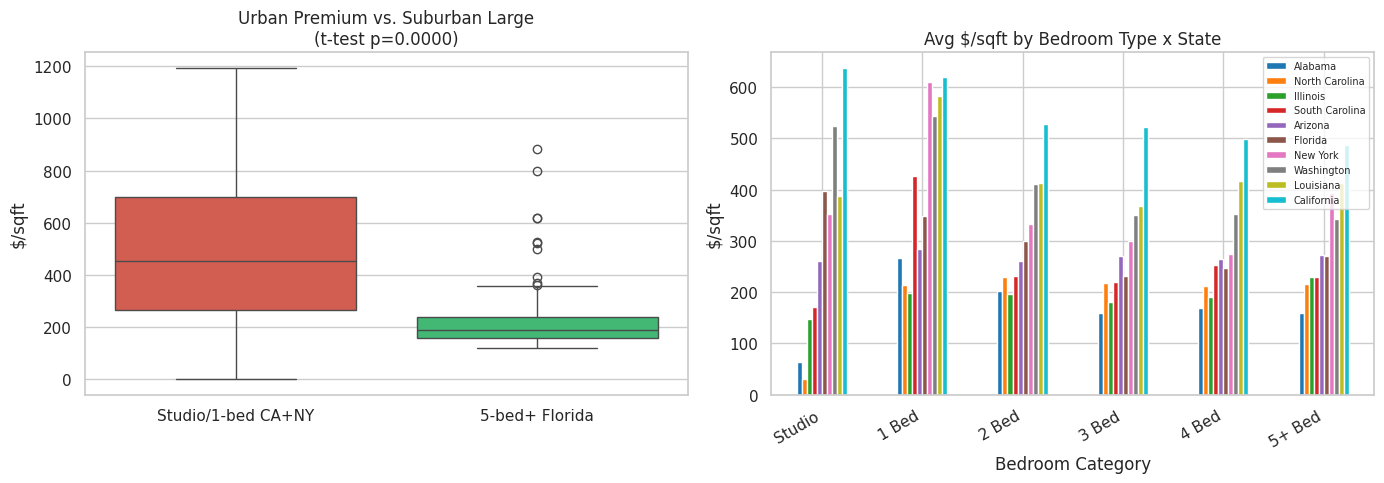

In [19]:
urban_premium = df_clean[
    (df_clean['state_name'].isin(['California', 'New York'])) &
    (df_clean['bed'] <= 1)
]['price_per_sqft']

suburban_large = df_clean[
    (df_clean['state_name'] == 'Florida') &
    (df_clean['bed'] >= 5)
]['price_per_sqft']

t_stat, t_p = stats.ttest_ind(urban_premium, suburban_large, equal_var=False)
premium_pct = 100 * (urban_premium.mean() - suburban_large.mean()) / suburban_large.mean()

print('Comparison: Studio/1-bed (CA+NY)  vs.  5-bed+ (Florida)')
print(f'  Urban CA/NY  n={len(urban_premium):,}  avg $/sqft: ${urban_premium.mean():.2f}')
print(f'  Suburban FL  n={len(suburban_large):,}   avg $/sqft: ${suburban_large.mean():.2f}')
print(f'  Premium:     ${urban_premium.mean() - suburban_large.mean():.2f}/sqft  ({premium_pct:.1f}% more expensive)')
print(f'  Welch t-test: t={t_stat:.3f}, p={t_p:.4f}')

insight_confirmed = t_p < 0.05 and urban_premium.mean() > suburban_large.mean()
print(f'  Expected Insight: {"CONFIRMED" if insight_confirmed else "NOT CONFIRMED"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_plot = pd.DataFrame({
    '$/sqft': pd.concat([urban_premium, suburban_large]),
    'Group':  ['Studio/1-bed CA+NY'] * len(urban_premium) + ['5-bed+ Florida'] * len(suburban_large)
})
sns.boxplot(
    data=data_plot[data_plot['$/sqft'] < data_plot['$/sqft'].quantile(0.97)],
    x='Group', y='$/sqft', palette=['#e74c3c', '#2ecc71'], ax=axes[0]
)
axes[0].set_title(f'Urban Premium vs. Suburban Large\n(t-test p={t_p:.4f})', fontsize=12)
axes[0].set_ylabel('$/sqft')
axes[0].set_xlabel('')

# Avg $/sqft by bed_category per state
pivot_plot = kpi1_pivot.drop(columns=['State Avg']).T
pivot_plot.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title('Avg $/sqft by Bedroom Type x State', fontsize=12)
axes[1].set_ylabel('$/sqft')
axes[1].set_xlabel('Bedroom Category')
axes[1].legend(fontsize=7, loc='upper right')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

---
## 6. Consolidated KPI Summary Dashboard

In [20]:
best_combo  = top_value.iloc[0]
worst_combo = kpi1_long.sort_values('avg_ppsqft', ascending=False).iloc[0]

kpi_summary = {
    # KPI 1
    'KPI1 -- National Avg $/sqft'              : f'${national_avg_ppsqft:.2f}',
    'KPI1 -- National Median $/sqft'           : f'${national_med_ppsqft:.2f}',
    'KPI1 -- Best-Value Entry Point'           : f"{best_combo['state_name']} x {best_combo['bed_category']} (${best_combo['avg_ppsqft']:.2f}/sqft)",
    'KPI1 -- Highest-Cost Combination'         : f"{worst_combo['state_name']} x {worst_combo['bed_category']} (${worst_combo['avg_ppsqft']:.2f}/sqft)",
    'KPI1 -- Value ZIP Codes Identified'       : f"{len(value_zips):,} across {value_zips['state_name'].nunique()} states",
    'KPI1 -- Cheapest State Avg $/sqft'        : f"{state_ppsqft.iloc[0]['state_name']} (${state_ppsqft.iloc[0]['avg_ppsqft']:.2f})",
    'KPI1 -- Most Expensive State Avg $/sqft'  : f"{state_ppsqft.iloc[-1]['state_name']} (${state_ppsqft.iloc[-1]['avg_ppsqft']:.2f})",
    # KPI 2
    'KPI2 -- State-Level ICI (HHI)'            : f'{ici_state:.4f}',
    'KPI2 -- City-Level ICI (HHI)'             : f'{ici_city:.6f}',
    'KPI2 -- Most Concentrated State'          : within_state_ici.iloc[0]['state_name'],
    'KPI2 -- Least Concentrated State'         : within_state_ici.iloc[-1]['state_name'],
    'KPI2 -- Top City by Listing Share'        : f"{top30_cities.iloc[0]['city']}, {top30_cities.iloc[0]['state_name']} ({top30_cities.iloc[0]['share_pct']:.2f}%)",
    # Expected Insight
    'Insight -- Size vs $/sqft Pearson r'      : f'{r_pearson:.4f}  (p={p_pearson:.2e})',
    'Insight -- Urban Premium (CA/NY vs FL)'   : f'${urban_premium.mean()-suburban_large.mean():.0f}/sqft  ({premium_pct:.1f}% more expensive)',
    'Insight -- Expected Hypothesis Result'    : 'CONFIRMED' if insight_confirmed else 'NOT CONFIRMED',
}

kpi_df = pd.DataFrame(kpi_summary.items(), columns=['Metric', 'Value'])
print('=== INVESTMENT KPI SUMMARY DASHBOARD ===')
display(kpi_df)

=== INVESTMENT KPI SUMMARY DASHBOARD ===


,Metric,Value
0,KPI1 -- National Avg $/sqft,$327.35
1,KPI1 -- National Median $/sqft,$261.50
2,KPI1 -- Best-Value Entry Point,Alabama x 5+ Bed ($158.63/sqft)
3,KPI1 -- Highest-Cost Combination,California x Studio ($636.16/sqft)
4,KPI1 -- Value ZIP Codes Identified,183 across 10 states
5,KPI1 -- Cheapest State Avg $/sqft,Alabama ($166.10)
6,KPI1 -- Most Expensive State Avg $/sqft,California ($516.74)
7,KPI2 -- State-Level ICI (HHI),0.1204
8,KPI2 -- City-Level ICI (HHI),0.002184
9,KPI2 -- Most Concentrated State,Arizona


---
## 7. Final Feature-Engineered Dataset & Export

In [21]:
# Price tier
q1, q2, q3 = df['price'].quantile([0.25, 0.50, 0.75])
def price_tier(p):
    if p <= q1:   return 'Budget'
    elif p <= q2: return 'Mid-Range'
    elif p <= q3: return 'Upper-Mid'
    else:         return 'Luxury'
df['price_tier'] = df['price'].apply(price_tier)

# Value ZIP flag
value_zip_set = set(zip(value_zips['state_name'], value_zips['zip_code'].astype(int)))
df['is_value_zip'] = df.apply(
    lambda r: 1 if (r['state_name'], int(r['zip_code'])) in value_zip_set else 0, axis=1
)
print(f'is_value_zip = 1 in {df["is_value_zip"].sum():,} rows')

# Deduplication check
dupes = df.duplicated(subset=['street', 'city', 'state_name', 'zip_code', 'price']).sum()
print(f'Duplicate rows (same address + price): {dupes}')
if dupes > 0:
    df = df.drop_duplicates(subset=['street', 'city', 'state_name', 'zip_code', 'price'])
    print(f'Rows after dedup: {len(df):,}')

is_value_zip = 1 in 1,537 rows
Duplicate rows (same address + price): 831
Rows after dedup: 10,579


In [22]:
output_dir = '../data/processed/'
os.makedirs(output_dir, exist_ok=True)

# 1. Full feature-engineered dataset
final_cols = [
    'date', 'month_num', 'day_of_week', 'is_weekend',
    'state_name', 'city', 'zip_code', 'street',
    'bed', 'bath', 'bed_category', 'bed_bath_ratio',
    'house_sqft', 'size_category',
    'price', 'log_price', 'price_per_sqft', 'price_tier',
    'log_sqft', 'has_broker', 'broker', 'is_value_zip'
]
df[final_cols].to_csv(f'{output_dir}final_house_data.csv', index=False)
print(f'Saved: final_house_data.csv  ({len(df):,} rows)')

# 2. KPI 1 - State x Bedroom avg $/sqft
kpi1_long.to_csv(f'{output_dir}kpi1_ppsqft_state_x_bed.csv', index=False)
print(f'Saved: kpi1_ppsqft_state_x_bed.csv')

# 3. KPI 1 Investment Ranking (sorted)
kpi1_long.sort_values('avg_ppsqft').to_csv(f'{output_dir}kpi1_investment_ranking.csv', index=False)
print(f'Saved: kpi1_investment_ranking.csv')

# 4. KPI 2 - Inventory Concentration
ici_export = within_state_ici.merge(
    state_ppsqft[['state_name', 'avg_ppsqft', 'median_ppsqft']], on='state_name'
)
ici_export.to_csv(f'{output_dir}kpi2_inventory_concentration.csv', index=False)
print(f'Saved: kpi2_inventory_concentration.csv')

# 5. Value ZIP Codes
value_zips.to_csv(f'{output_dir}value_zip_codes.csv', index=False)
print(f'Saved: value_zip_codes.csv  ({len(value_zips)} rows)')

print('\nAll files exported successfully.')

Saved: final_house_data.csv  (10,579 rows)
Saved: kpi1_ppsqft_state_x_bed.csv
Saved: kpi1_investment_ranking.csv
Saved: kpi2_inventory_concentration.csv
Saved: value_zip_codes.csv  (183 rows)

All files exported successfully.


## 8. Output File Schema

| File | Contents | Use Case |
|---|---|---|
| `final_house_data.csv` | All listings + engineered features + `is_value_zip` flag | ML models, dashboards |
| `kpi1_ppsqft_state_x_bed.csv` | Avg $/sqft per State x Bedroom with counts and discounts | Fund allocation table |
| `kpi1_investment_ranking.csv` | All combos ranked cheapest to priciest $/sqft | Ranked entry point report |
| `kpi2_inventory_concentration.csv` | State-level HHI + avg $/sqft | Market saturation analysis |
| `value_zip_codes.csv` | ZIP codes below-avg $/sqft with high demand | Targeted acquisition shortlist |

---
*Pipeline complete. Data is ready for dashboard ingestion, fund allocation reporting, or predictive modelling.*